In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_set = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle=False)

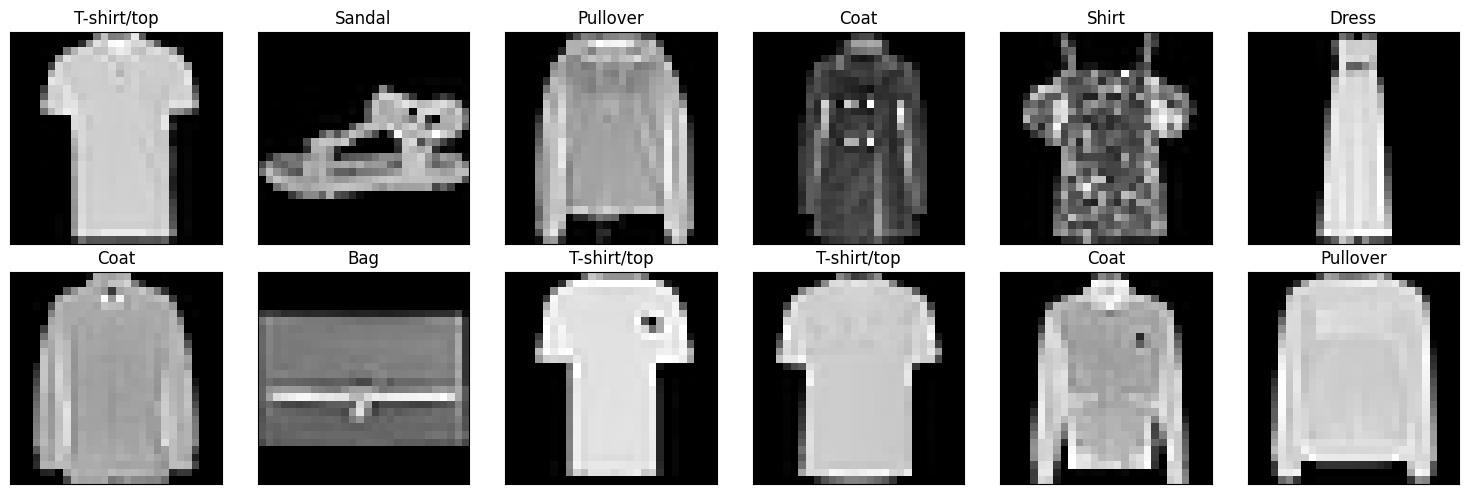

In [15]:
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
dataiter = iter(train_loader)
images, labels = next(dataiter)

fig = plt.figure(figsize=(15, 5))
for idx in range(12):
    ax = fig.add_subplot(2, 6, idx+1, xticks=[], yticks=[])

    img = images[idx].numpy().squeeze()
    img = img * 0.5 + 0.5

    ax.imshow(img, cmap='gray')
    ax.set_title(classes[labels[idx]])

plt.tight_layout()
plt.show()

In [75]:
model_1 = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)
optimizer = optim.SGD(model_1.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()


In [76]:
epochs= 15
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model_1.train()
    total_loss = 0
    correct = 0

    for images, labels in train_loader:
        images = images.view(-1, 784)

        outputs = model_1(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    loss = total_loss / len(train_loader)
    accuracie = 100 * correct / len(train_loader.dataset)

    train_losses.append(loss)
    train_accuracies.append(accuracie)
    print(f"Epoch {epoch+1}: Loss = {loss:.4f}, Acc = {accuracie:.2f}%")

Epoch 1: Loss = 1.0072, Acc = 67.31%
Epoch 2: Loss = 0.5613, Acc = 79.80%
Epoch 3: Loss = 0.4920, Acc = 82.48%
Epoch 4: Loss = 0.4564, Acc = 83.72%
Epoch 5: Loss = 0.4333, Acc = 84.56%
Epoch 6: Loss = 0.4155, Acc = 85.16%
Epoch 7: Loss = 0.4019, Acc = 85.58%
Epoch 8: Loss = 0.3894, Acc = 85.95%
Epoch 9: Loss = 0.3788, Acc = 86.35%
Epoch 10: Loss = 0.3696, Acc = 86.70%
Epoch 11: Loss = 0.3597, Acc = 87.05%
Epoch 12: Loss = 0.3520, Acc = 87.34%
Epoch 13: Loss = 0.3452, Acc = 87.62%
Epoch 14: Loss = 0.3386, Acc = 87.86%
Epoch 15: Loss = 0.3321, Acc = 87.99%


In [77]:
model_1.eval()
test_correct = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(-1, 784)
        outputs = model_1(images)
        test_correct += (outputs.argmax(1) == labels).sum().item()

test_acc = 100 * test_correct / len(test_loader.dataset)
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 86.35%


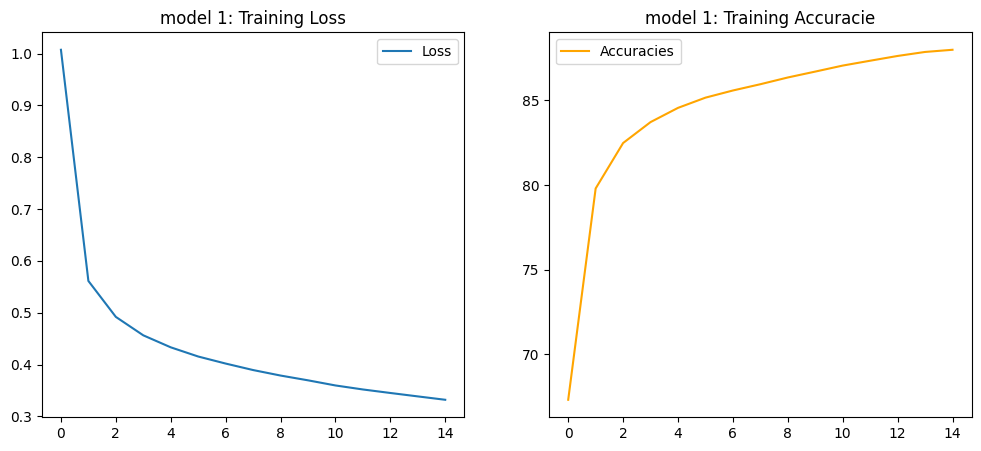

In [78]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Loss')
plt.title('model 1: Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Accuracies', color='orange')
plt.title('model 1: Training Accuracie')
plt.legend()
plt.show()

### Experiment model 2(Optional)
Relu

BatchNorm1d

Dropout



In [79]:
model_2 = nn.Sequential(
    nn.Linear(784, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, 10)
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_2.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [80]:
epochs= 15
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model_2.train()
    total_loss = 0
    correct = 0

    for images, labels in train_loader:
        images = images.view(-1, 784)

        outputs = model_2(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    loss = total_loss / len(train_loader)
    accuracie = 100 * correct / len(train_loader.dataset)

    train_losses.append(loss)
    train_accuracies.append(accuracie)

    print(f"Epoch {epoch+1}: Loss = {loss:.4f}, Acc = {accuracie:.2f}%")

Epoch 1: Loss = 0.6081, Acc = 80.08%
Epoch 2: Loss = 0.4417, Acc = 84.48%
Epoch 3: Loss = 0.4078, Acc = 85.35%
Epoch 4: Loss = 0.3876, Acc = 86.18%
Epoch 5: Loss = 0.3689, Acc = 86.71%
Epoch 6: Loss = 0.3559, Acc = 87.11%
Epoch 7: Loss = 0.3432, Acc = 87.58%
Epoch 8: Loss = 0.3375, Acc = 87.75%
Epoch 9: Loss = 0.3279, Acc = 88.08%
Epoch 10: Loss = 0.3201, Acc = 88.42%
Epoch 11: Loss = 0.3136, Acc = 88.62%
Epoch 12: Loss = 0.3105, Acc = 88.55%
Epoch 13: Loss = 0.3031, Acc = 88.92%
Epoch 14: Loss = 0.2984, Acc = 89.11%
Epoch 15: Loss = 0.2982, Acc = 89.02%


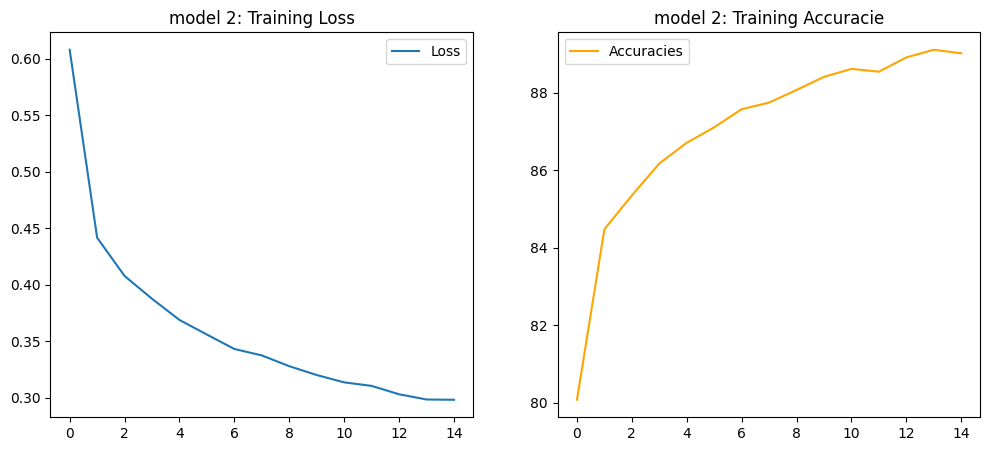

In [81]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Loss')
plt.title('model 2: Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Accuracies', color='orange') # [cite: 175]
plt.title('model 2: Training Accuracie')
plt.legend()
plt.show()

In [83]:
model_2.eval()
test_correct = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(-1, 784)

        outputs = model_2(images)

        test_correct += (outputs.argmax(1) == labels).sum().item()

test_acc = 100 * test_correct / len(test_loader.dataset)
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 88.77%


### Experiment model 2(Optional)
tahn

BatchNorm1d

Dropout

Adam


In [85]:
model_3 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 512),
    nn.BatchNorm1d(512),
    nn.Tanh(),
    nn.Dropout(0.3),

    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.Tanh(),
    nn.Dropout(0.3),

    nn.Linear(256, 10)
)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_3.parameters(), lr=0.01)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [87]:
epochs= 20
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model_3.train()
    total_loss = 0
    correct = 0

    for images, labels in train_loader:
        images = images.view(-1, 784)

        outputs = model_3(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    loss = total_loss / len(train_loader)
    accuracie = 100 * correct / len(train_loader.dataset)

    train_losses.append(loss)
    train_accuracies.append(accuracie)

    print(f"Epoch {epoch+1}: Loss = {loss:.4f}, Acc = {accuracie:.2f}%")

Epoch 1: Loss = 0.4613, Acc = 83.45%
Epoch 2: Loss = 0.4199, Acc = 84.94%
Epoch 3: Loss = 0.3922, Acc = 85.87%
Epoch 4: Loss = 0.3768, Acc = 86.22%
Epoch 5: Loss = 0.3653, Acc = 86.70%
Epoch 6: Loss = 0.3495, Acc = 87.32%
Epoch 7: Loss = 0.3404, Acc = 87.75%
Epoch 8: Loss = 0.3323, Acc = 87.91%
Epoch 9: Loss = 0.3219, Acc = 88.11%
Epoch 10: Loss = 0.3130, Acc = 88.54%
Epoch 11: Loss = 0.3096, Acc = 88.77%
Epoch 12: Loss = 0.3031, Acc = 88.89%
Epoch 13: Loss = 0.2918, Acc = 89.47%
Epoch 14: Loss = 0.2897, Acc = 89.40%
Epoch 15: Loss = 0.2832, Acc = 89.71%
Epoch 16: Loss = 0.2765, Acc = 89.84%
Epoch 17: Loss = 0.2756, Acc = 90.00%
Epoch 18: Loss = 0.2684, Acc = 90.13%
Epoch 19: Loss = 0.2673, Acc = 90.31%
Epoch 20: Loss = 0.2617, Acc = 90.36%


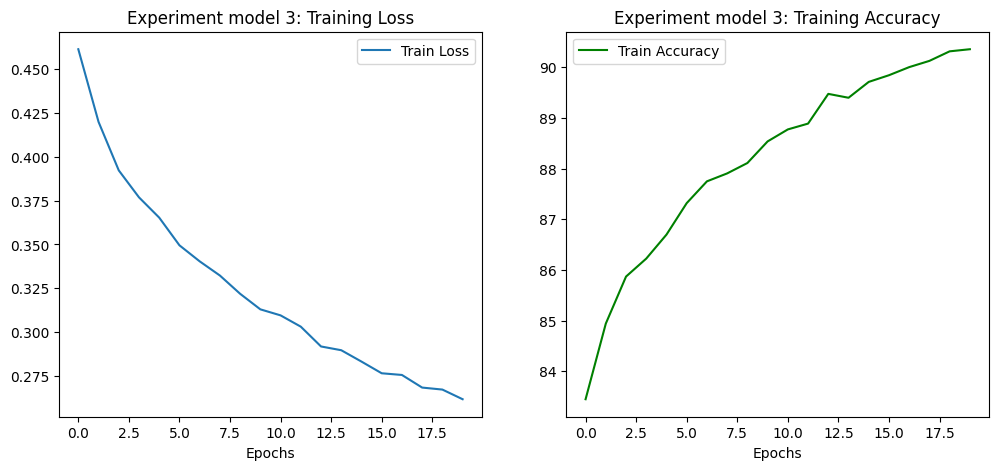

In [88]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.title('Experiment model 3: Training Loss')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', color='green')
plt.title('Experiment model 3: Training Accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.show()

In [90]:
model_3.eval()
test_correct = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(-1, 784)

        outputs = model_3(images)

        test_correct += (outputs.argmax(1) == labels).sum().item()

test_acc = 100 * test_correct / len(test_loader.dataset)
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 88.74%
